In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Jan 06 10:35:11 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 06 10:35:11 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def bin_features(list_cols, X, y, dict_monotone_constraints, int_n_bins):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # copy the original
        int_n_bins_tmp = int_n_bins
        
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
        
        # logic for some features
        list_cols_uniform = [
            'ENG-loan_to_value',
            'ENG-payment_to_income',
            'flt_avg_open__tu_pmthx',
            'flt_wtd_avg_open__tu_pmthx',
            'flt_avg_closed__tu_pmthx',
            'flt_wtd_avg_closed__tu_pmthx',
            'ENG-payment_trend_open',
            'ENG-payment_trend_closed',
            'addrchangecount12month__ln',
            'dti__app',
            'fltgrossmonthly__income_sum',
            'miles_odometer__app',
            'ENG-vehicle_age',
        ]
        # logic for ltv
        if col in list_cols_uniform:
            str_prebinning_method = 'uniform'
        else:
            str_prebinning_method = 'cart'
        
        # make sure maximum number of bins are showing
        while True:
            # init
            cls_binning = OptimalBinning(
                name=col,
                dtype='numerical',
                solver='cp',
                monotonic_trend=str_monotonic_trend,
                min_n_bins=int_n_bins_tmp,
                max_n_bins=int_n_bins_tmp,
                prebinning_method=str_prebinning_method,
            )
            # fit
            cls_binning.fit(
                X[col],
                y,
            )
            # assign
            dict_bins[col] = cls_binning

            # transform
            str_col = f'{col}_binned'
            X[str_col] = cls_binning.transform(
                X[col],
                metric='woe',
            )

            # get count unique
            int_n_unique = X[str_col].nunique()
            
            # logic
            if int_n_unique == int_n_bins_tmp:
                break
            else:
                # subtract
                int_n_bins_tmp -= 1
            
            # logic
            if int_n_bins_tmp == 0:
                break
            else:
                pass

        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X

#### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = 'Early_Pay_Delinquency_60_720_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

str_task_tmp = '13_60_in_720_dl'

Project: 20241112-simple-model-test
Task: create_grid
Subtask: 02_60_in_720_loss
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [5]:
str_filename = 'df_holdout.gzip'
str_uri = f's3://{str_project}/{str_task_tmp}/01_data_split/{str_filename}'
df = pd.read_parquet(
    str_uri,
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_closed,ENG-trending_up_open,ENG-trending_up_closed,request_month,train,valid,test,inform,holdout,data_set
37939,6377872,2022-10-15 03:05:13+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-10-14.gzip,0,0,North Carolina,Independent,North Carolina,False,...,0,1,0,2022-10-01,0,0,0,0,1,holdout
35558,6345230,2022-10-12 01:19:28+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-10-11.gzip,1,1,Arizona,Independent,Arizona,False,...,0,1,1,2022-10-01,0,0,0,0,1,holdout
39136,6379734,2022-10-25 05:31:28+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-10-24.gzip,1,1,Illinois,Franchise,Illinois,False,...,0,1,1,2022-10-01,0,0,0,0,1,holdout
38041,6349527,2022-10-15 04:27:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-10-14.gzip,0,0,Washington,Franchise,Washington,False,...,0,0,0,2022-10-01,0,0,0,0,1,holdout
38040,6349527,2022-10-15 04:27:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-10-14.gzip,1,1,Washington,Franchise,Washington,False,...,0,0,0,2022-10-01,0,0,0,0,1,holdout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42089,6464887,2022-12-06 22:54:50+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-06.gzip,1,1,Illinois,Franchise,Illinois,True,...,1,1,1,2022-12-01,0,0,0,0,1,holdout
42197,6464638,2022-12-07 23:13:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-07.gzip,1,1,Virginia,Independent,Virginia,False,...,1,0,1,2022-12-01,0,0,0,0,1,holdout
41923,6464416,2022-12-03 00:37:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-02.gzip,1,1,Utah,Independent,Utah,False,...,1,1,1,2022-12-01,0,0,0,0,1,holdout
42062,6465473,2022-12-06 07:13:43+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-12-06.gzip,1,1,Alabama,Franchise,Alabama,False,...,0,0,0,2022-12-01,0,0,0,0,1,holdout


#### List of columns

In [6]:
list_cols = [
    'fltgrossmonthly__income_sum',
    'ENG-loan_to_value',
    'ENG-payment_to_income',
    'dti__app',
    'flt_avg_open__tu_pmthx',
    'flt_avg_closed__tu_pmthx',
    'flt_wtd_avg_open__tu_pmthx',
    'flt_wtd_avg_closed__tu_pmthx',
    'fltdowncash__app',
    'fltapproveddowntotal__app',
    'miles_odometer__app',
    'ENG-vehicle_age',
]

#### Impute

In [7]:
str_filename = 'dict_impute.pkl'
str_local_path = f'../../10_60_in_720_test/02_model/output/{str_filename}'
dict_impute = pickle.load(open(str_local_path, 'rb'))

dict_impute['ENG-payment_to_income'] = df['ENG-payment_to_income'].max()
dict_impute['flt_avg_open__tu_pmthx'] = 0
dict_impute['flt_avg_closed__tu_pmthx'] = 0
dict_impute['fltdowncash__app'] = 0
dict_impute['fltapproveddowntotal__app'] = 0
dict_impute['miles_odometer__app'] = df['miles_odometer__app'].max()
dict_impute['ENG-vehicle_age'] = df['ENG-vehicle_age'].max()

# impute
for key, val in tqdm(dict_impute.items()):
    df[key] = df[key].fillna(val)

100%|██████████| 26/26 [00:00<00:00, 3210.15it/s]


#### Monotonic constraints

In [8]:
# get monotonic constraints
dict_monotone_constraints = {
    'fltgrossmonthly__income_sum': -1,
    'ENG-loan_to_value': 1,
    'ENG-payment_to_income': 1,
    'dti__app': 1,
    'flt_avg_open__tu_pmthx': -1,
    'flt_avg_closed__tu_pmthx': -1,
    'flt_wtd_avg_open__tu_pmthx': -1,
    'flt_wtd_avg_closed__tu_pmthx': -1,
    'fltdowncash__app': -1,
    'fltapproveddowntotal__app': -1,
    'miles_odometer__app': 1,
    'ENG-vehicle_age': 1,
}
dict_bins, list_cols_scorecard, X = bin_features(
    list_cols=list_cols,
    X=df[list_cols].copy(),
    y=df[str_target],
    dict_monotone_constraints=dict_monotone_constraints,
    int_n_bins=5,
)

100%|██████████| 12/12 [00:01<00:00, 10.75it/s]


In [9]:
# show bins
df_tmp = X.copy()
df_tmp['target'] = df[str_target]
list_df = []
for col in tqdm(list_cols_scorecard):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)

# make df
df_bins = pd.concat(list_df)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

100%|██████████| 12/12 [00:00<00:00, 193.99it/s]


,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.071987,0.000000,4109.000000,4135,0.530196,0.230230,1
1,fltgrossmonthly__income_sum_binned,-0.001778,4110.000000,4696.000000,1032,0.132325,0.218023,2
2,fltgrossmonthly__income_sum_binned,0.069701,4697.000000,7629.000000,2203,0.282472,0.206083,3
3,fltgrossmonthly__income_sum_binned,0.322562,7643.000000,9966.000000,304,0.038979,0.167763,4
4,fltgrossmonthly__income_sum_binned,0.639758,10000.000000,11741.980000,125,0.016028,0.128000,5
4,ENG-loan_to_value_binned,2.133246,0.348836,0.863219,94,0.012053,0.031915,1
3,ENG-loan_to_value_binned,0.377839,0.870013,1.074944,643,0.082446,0.160187,2
2,ENG-loan_to_value_binned,0.170135,1.075101,1.178542,1115,0.142967,0.190135,3
1,ENG-loan_to_value_binned,0.076521,1.178786,1.282427,1932,0.247724,0.204969,4
0,ENG-loan_to_value_binned,-0.153980,1.282439,2.423500,4015,0.514810,0.245081,5


#### Plot

  0%|          | 0/12 [00:00<?, ?it/s]

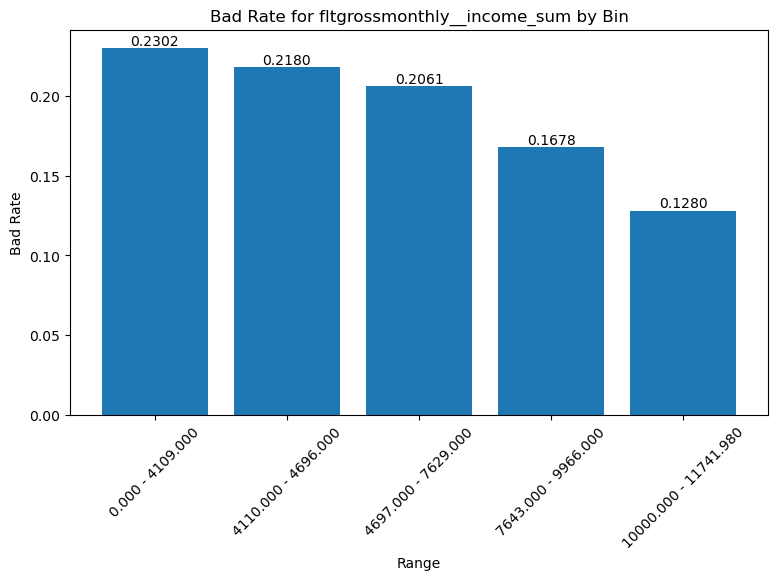

  8%|▊         | 1/12 [00:00<00:02,  4.12it/s]

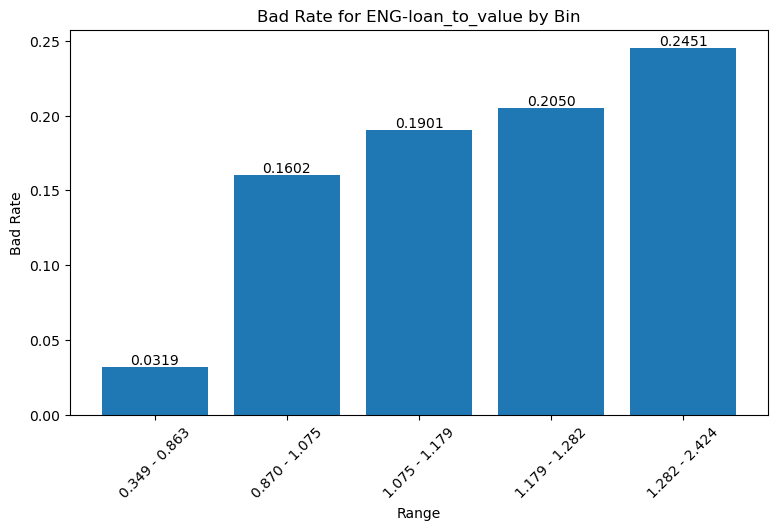

 17%|█▋        | 2/12 [00:00<00:01,  5.64it/s]

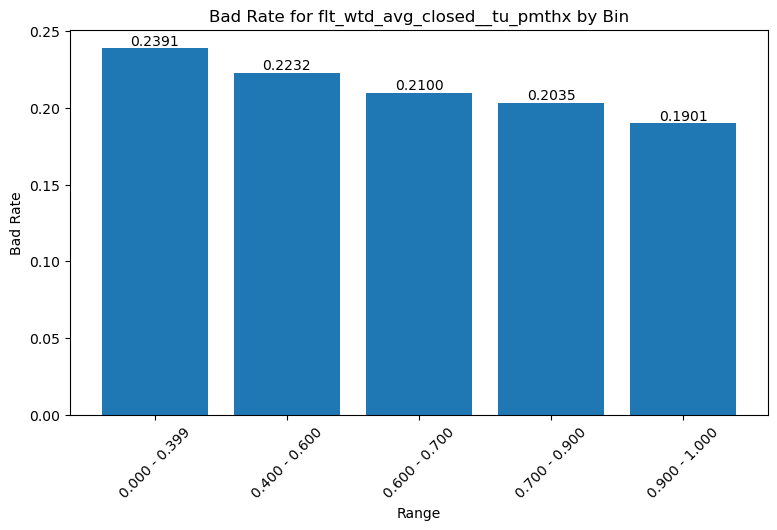

 25%|██▌       | 3/12 [00:00<00:01,  6.43it/s]

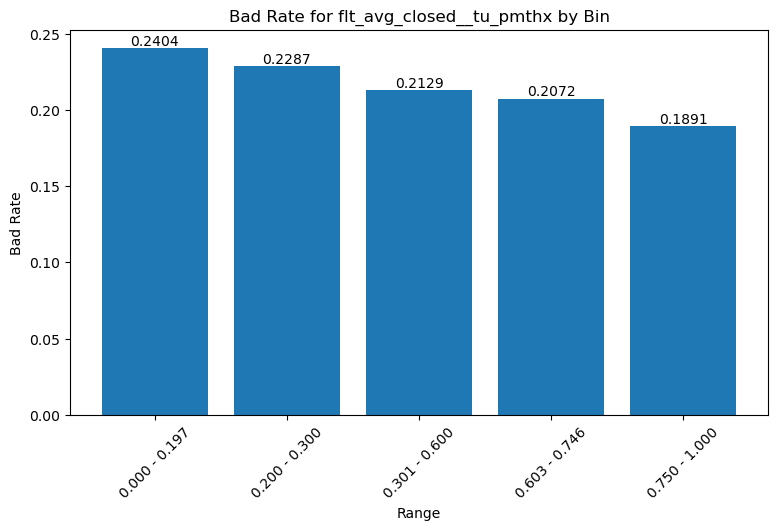

 33%|███▎      | 4/12 [00:00<00:01,  6.86it/s]

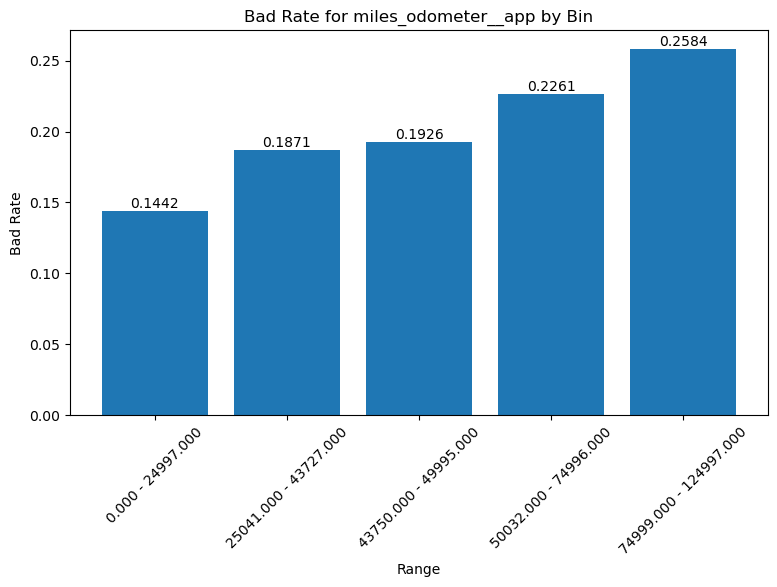

 42%|████▏     | 5/12 [00:00<00:00,  7.04it/s]

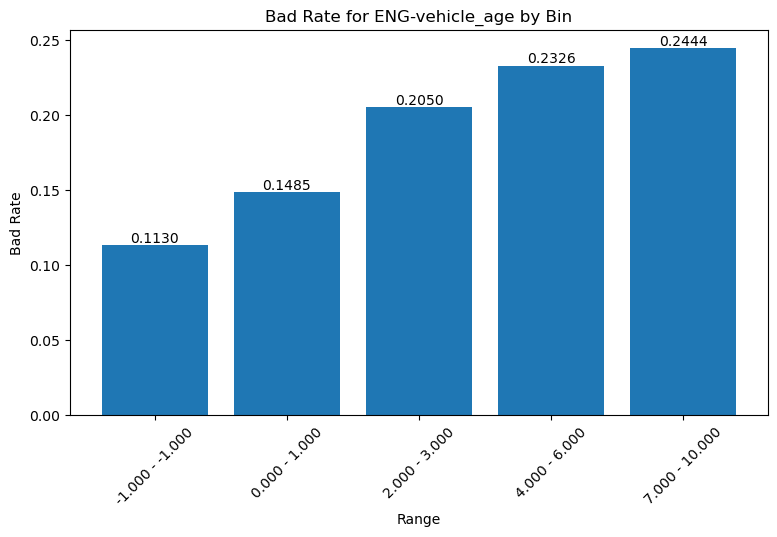

 50%|█████     | 6/12 [00:00<00:00,  7.24it/s]

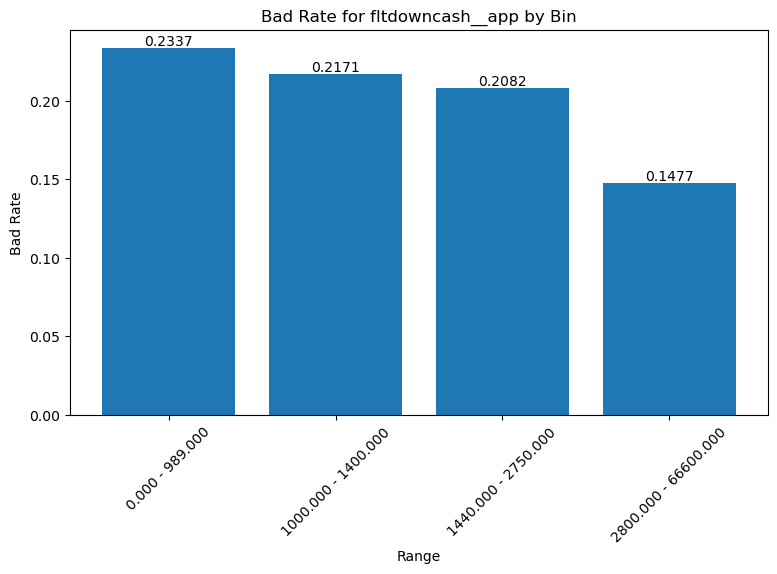

 58%|█████▊    | 7/12 [00:01<00:00,  7.55it/s]

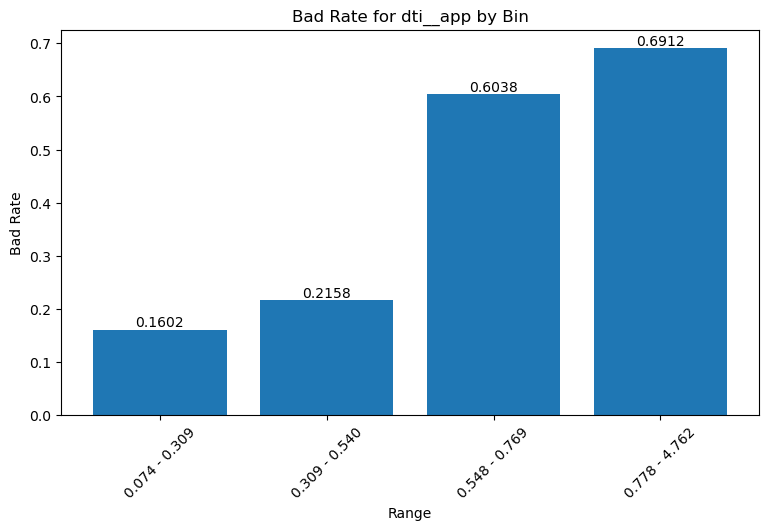

 67%|██████▋   | 8/12 [00:01<00:00,  7.61it/s]

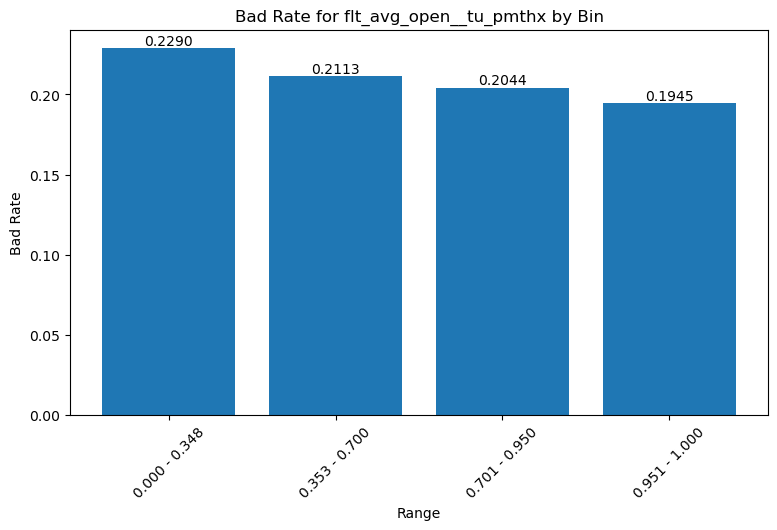

 75%|███████▌  | 9/12 [00:01<00:00,  7.87it/s]

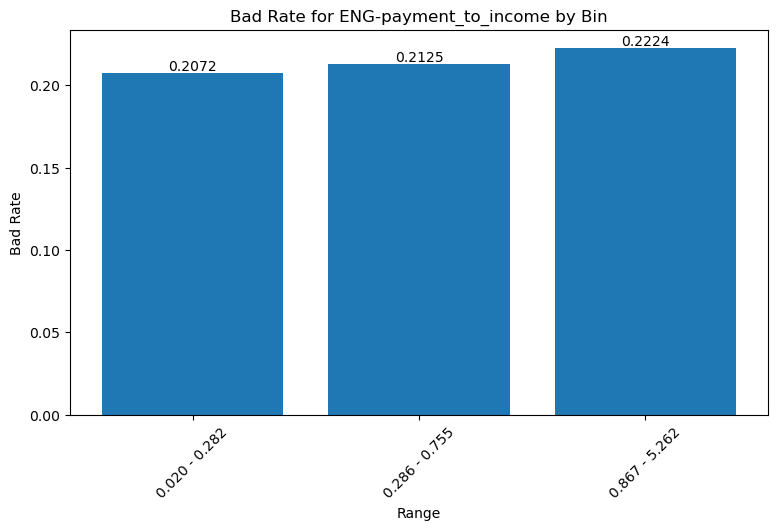

 83%|████████▎ | 10/12 [00:01<00:00,  8.21it/s]

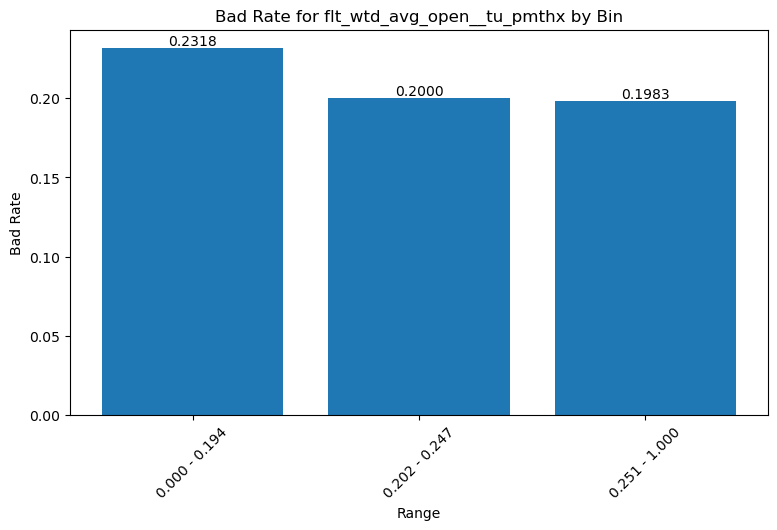

 92%|█████████▏| 11/12 [00:01<00:00,  8.48it/s]

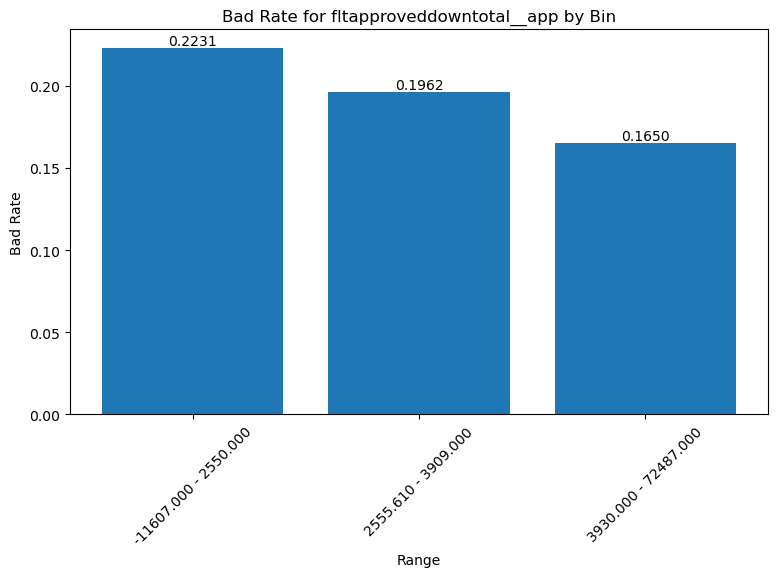

100%|██████████| 12/12 [00:01<00:00,  7.49it/s]


In [10]:
df_bins['label'] = df_bins.apply(
    lambda x: f"{x['min']:0.3f} - {x['max']:0.3f}",
    axis=1,
)

df_bins['feature_tmp'] = df_bins['feature'].apply(
    lambda x: x.split('_binned')[0],
)
list_cols = list(df_bins['feature_tmp'].value_counts().index)
# plot
for col in tqdm(list_cols):
    df_tmp = df_bins[df_bins['feature_tmp'] == col].copy()
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Bad Rate for {col} by Bin')
    ax.set_xlabel('Range')
    ax.set_ylabel('Bad Rate')
    bars = ax.bar(df_tmp['label'], df_tmp['target'])
    ax.bar_label(bars, fmt='%.4f')
    ax.set_xticklabels(df_tmp['label'], rotation=45)
    plt.show()

#### Misc

In [17]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'fltgrossmonthly__income_sum': 'sum',
})
int_n = df_tmp[df_tmp['fltgrossmonthly__income_sum'] < 2500].shape[0]
flt_prop = int_n / df_tmp.shape[0]
flt_prop

0.03389029003783102